# Proyek Akhir: Sistem Rekomendasi Buku

## 1. Pendahuluan

Dalam era digital yang penuh dengan informasi, pengguna sering kesulitan menemukan buku yang sesuai minat mereka.  
Proyek ini mengimplementasikan sistem rekomendasi buku berbasis Content-Based Filtering dan Collaborative Filtering  dengan menggunakan data dari komunitas Book-Crossing untuk membantu menyajikan rekomendasi yang lebih relevan.

**Sumber Dataset :** [Kumpulan Data Rekomendasi Buku](https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset)

## 2. Import Library

Pada tahap ini dilakukan import library yang diperlukan untuk analisis data, visualisasi, dan pemodelan machine learning.

In [68]:
# Import Pustaka
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from scipy.sparse.linalg import svds
import os

import zipfile
from google.colab import files
from google.colab import drive

Muat dataset dari Google Drive

In [69]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Ekstraksi ZIP Dataset

In [70]:
zip_path = "/content/drive/MyDrive/Proyek Akhir MLT/Dataset.zip"
extract_path = "dataset"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset berhasil diekstrak.")
else:
    print("Folder sudah ada, tidak perlu ekstrak ulang.")

Folder sudah ada, tidak perlu ekstrak ulang.


## Cek isi folder

Menampilkan isi folder dataset untuk memastikan file telah berhasil diekstrak dan tersedia untuk diproses.

In [71]:
path_kelas = "/content/dataset"
print("Isi dalam dataset:")
print(os.listdir(path_kelas))

Isi dalam dataset:
['Ratings.csv', 'age_distribution.png', 'Users.csv', 'recsys_taxonomy2.png', 'DeepRec.png', 'year_distribution.png', 'Books.csv', 'Ratings.png', 'classicRec.png']


## 4. Data Understanding

Memulai tahap pemahaman data dengan menentukan lokasi file dataset dan menampilkan informasi awal dari masing-masing file (Books, Ratings, Users).

In [72]:
print("\n--- Memulai Tahap Data Understanding ---")

# Lokasi dataset
dataset_path = "/content/dataset"
books_file = os.path.join(dataset_path, "Books.csv")
ratings_file = os.path.join(dataset_path, "Ratings.csv")
users_file = os.path.join(dataset_path, "Users.csv")


--- Memulai Tahap Data Understanding ---


### Memuat dataset

Membaca file CSV ke dalam DataFrame pandas. Jika terjadi error pada encoding, mencoba encoding alternatif. Menampilkan info dan contoh data dari masing-masing dataset.

In [73]:
print(f"Memuat dataset dari {dataset_path}...")
try:
    # Menggunakan kutip tunggal standar, tanpa backslash escape
    books = pd.read_csv(books_file, encoding='latin-1', low_memory=False, on_bad_lines='skip')
    ratings = pd.read_csv(ratings_file, encoding='latin-1', on_bad_lines='skip')
    users = pd.read_csv(users_file, encoding='latin-1', on_bad_lines='skip')
    print("Dataset berhasil dimuat.")
except FileNotFoundError:
    print(f"Error: Pastikan file Books.csv, Ratings.csv, dan Users.csv ada di direktori {dataset_path}")
    exit()
except Exception as e:
    print(f"Terjadi error saat memuat dataset: {e}")
    # Mencoba encoding lain jika latin-1 gagal total
    try:
        print("Mencoba memuat dengan encoding cp1252...")
        books = pd.read_csv(books_file, encoding='cp1252', low_memory=False, on_bad_lines='skip')
        ratings = pd.read_csv(ratings_file, encoding='cp1252', on_bad_lines='skip')
        users = pd.read_csv(users_file, encoding='cp1252', on_bad_lines='skip')
        print("Dataset berhasil dimuat dengan encoding cp1252.")
    except Exception as e2:
        print(f"Gagal memuat dataset dengan encoding alternatif: {e2}")
        exit()

Memuat dataset dari /content/dataset...
Dataset berhasil dimuat.


### Tampilkan informasi awal dataset

In [74]:
print("\nInformasi Dataset Books:")
books.info()
print("\nContoh Data Books:")
print(books.head())

print("\nInformasi Dataset Ratings:")
ratings.info()
print("\nContoh Data Ratings:")
print(ratings.head())

print("\nInformasi Dataset Users:")
users.info()
print("\nContoh Data Users:")
print(users.head())


Informasi Dataset Books:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB

Contoh Data Books:
         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story o

### EDA & Visualisasi

#### Cek missing values

Melakukan pengecekan jumlah nilai yang hilang (missing values) pada setiap kolom di ketiga dataset.

In [75]:
print("\nJumlah Missing Values per Kolom:")
print("Books:\n", books.isnull().sum())
print("\nRatings:\n", ratings.isnull().sum())
print("\nUsers:\n", users.isnull().sum())


Jumlah Missing Values per Kolom:
Books:
 ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

Ratings:
 User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

Users:
 User-ID          0
Location         0
Age         110762
dtype: int64


#### Cek duplikat

Melakukan pengecekan jumlah data duplikat pada setiap dataset berdasarkan kolom kunci.


In [76]:
print("\nJumlah Duplikat:")
print("Books (berdasarkan ISBN):", books.duplicated(subset='ISBN').sum())
print("Ratings (berdasarkan User-ID dan ISBN):", ratings.duplicated(subset=['User-ID', 'ISBN']).sum())
print("Users (berdasarkan User-ID):", users.duplicated(subset='User-ID').sum())


Jumlah Duplikat:
Books (berdasarkan ISBN): 0
Ratings (berdasarkan User-ID dan ISBN): 0
Users (berdasarkan User-ID): 0


#### Eksplorasi Data Ratings

Menampilkan distribusi nilai rating buku untuk mengetahui sebaran rating yang diberikan pengguna.

In [77]:
print("\nDistribusi Book-Rating:")
rating_counts = ratings['Book-Rating'].value_counts().sort_index()
print(rating_counts)


Distribusi Book-Rating:
Book-Rating
0     716109
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64


#### Visualisasi Distribusi Rating (Simpan ke file)

Membuat visualisasi distribusi rating buku dan menyimpannya ke file gambar.

Visualisasi distribusi rating disimpan di: /content/dataset/Ratings.png


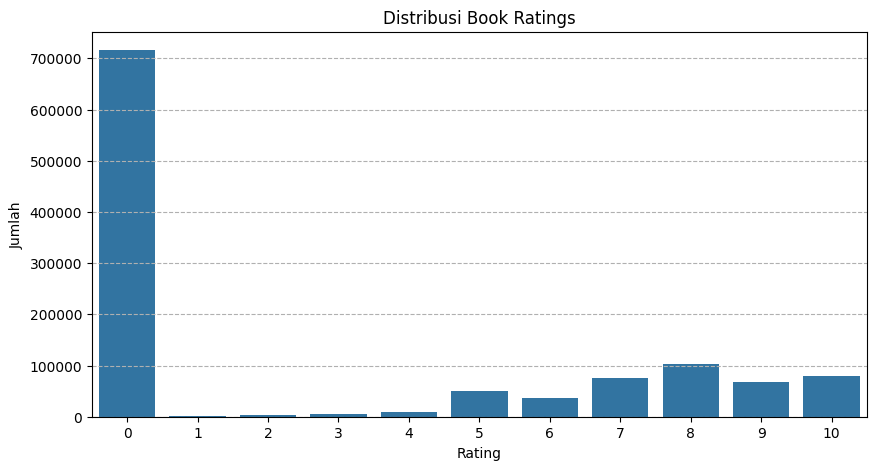

In [78]:
plt.figure(figsize=(10, 5))
sns.countplot(data=ratings, x='Book-Rating')
plt.title('Distribusi Book Ratings')
plt.xlabel('Rating')
plt.ylabel('Jumlah')
plt.grid(axis='y', linestyle='--')

# Simpan ke file
rating_dist_path = "/content/dataset/Ratings.png"
plt.savefig(rating_dist_path)
print(f"Visualisasi distribusi rating disimpan di: {rating_dist_path}")

# Tampilkan ke layar
plt.show()

# Tutup plot agar tidak membebani memori
plt.close()

#### Eksplorasi Data Users (Age)

Menampilkan statistik deskriptif kolom usia pengguna untuk mengetahui rentang dan sebaran usia.

In [79]:
print("\nStatistik Deskriptif Kolom Age:")
print(users['Age'].describe())


Statistik Deskriptif Kolom Age:
count    168096.000000
mean         34.751434
std          14.428097
min           0.000000
25%          24.000000
50%          32.000000
75%          44.000000
max         244.000000
Name: Age, dtype: float64


#### Mengatasi nilai usia yang tidak realistis

Membersihkan data usia dengan hanya mengambil pengguna berusia antara 5 hingga 100 tahun.

In [80]:
users_cleaned_age = users[(users['Age'] >= 5) & (users['Age'] <= 100)]

#### Visualisasi Distribusi Usia Pengguna (Setelah Cleaning)

Membuat visualisasi distribusi usia pengguna setelah data dibersihkan dan menyimpannya ke file gambar.

Visualisasi distribusi usia disimpan di: /content/dataset/age_distribution.png


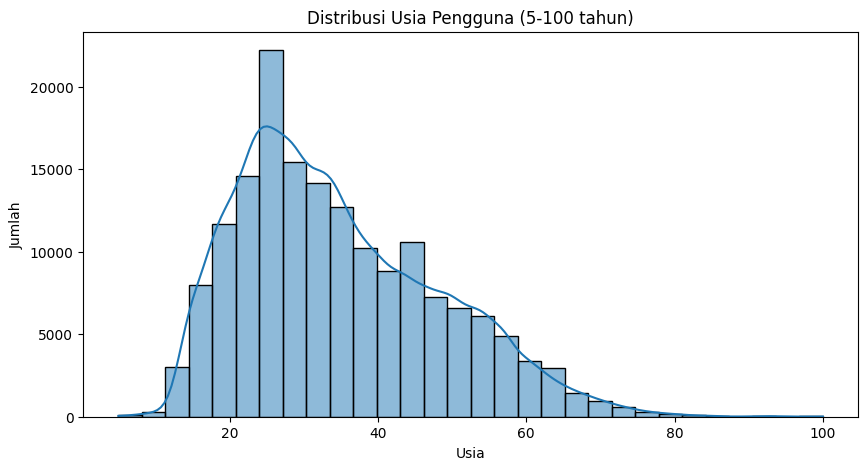

In [81]:
plt.figure(figsize=(10, 5))
sns.histplot(users_cleaned_age['Age'], bins=30, kde=True)
plt.title('Distribusi Usia Pengguna (5-100 tahun)')
plt.xlabel('Usia')
plt.ylabel('Jumlah')

# Simpan ke file
age_dist_path = "/content/dataset/age_distribution.png"
plt.savefig(age_dist_path)
print(f"Visualisasi distribusi usia disimpan di: {age_dist_path}")

# Tampilkan grafik di notebook
plt.show()

# Tutup plot
plt.close()

#### Eksplorasi Data Books (Year-Of-Publication)

Memeriksa tipe data dan contoh nilai unik pada kolom tahun terbit buku.

In [82]:
print("\nMemeriksa Kolom Year-Of-Publication:")
print("Tipe data awal:", books['Year-Of-Publication'].dtype)
print("Contoh nilai unik:", books['Year-Of-Publication'].unique()[:20])


Memeriksa Kolom Year-Of-Publication:
Tipe data awal: object
Contoh nilai unik: ['2002' '2001' '1991' '1999' '2000' '1993' '1996' '1988' '2004' '1998'
 '1994' '2003' '1997' '1983' '1979' '1995' '1982' '1985' '1992' '1986']


#### Konversi ke numerik

Mengonversi kolom tahun terbit ke tipe numerik dan mengecek jumlah nilai NaN setelah konversi.

In [83]:
books['Year-Of-Publication'] = pd.to_numeric(books['Year-Of-Publication'], errors='coerce')

# Cek nilai NaN setelah konversi
print("Jumlah NaN setelah konversi:", books['Year-Of-Publication'].isnull().sum())

Jumlah NaN setelah konversi: 3


#### Mengatasi tahun yang tidak valid

Membersihkan data tahun terbit dengan hanya mengambil tahun yang valid (lebih dari 0 dan tidak melebihi tahun sekarang).

In [84]:
current_year = pd.Timestamp.now().year
books_cleaned_year = books[(books['Year-Of-Publication'] > 0) & (books['Year-Of-Publication'] <= current_year)]

#### Visualisasi Distribusi Tahun Publikasi (Setelah Cleaning)

Membuat visualisasi distribusi tahun terbit buku setelah data dibersihkan dan menyimpannya ke file gambar.

Visualisasi distribusi tahun publikasi disimpan di: /content/dataset/year_distribution.png


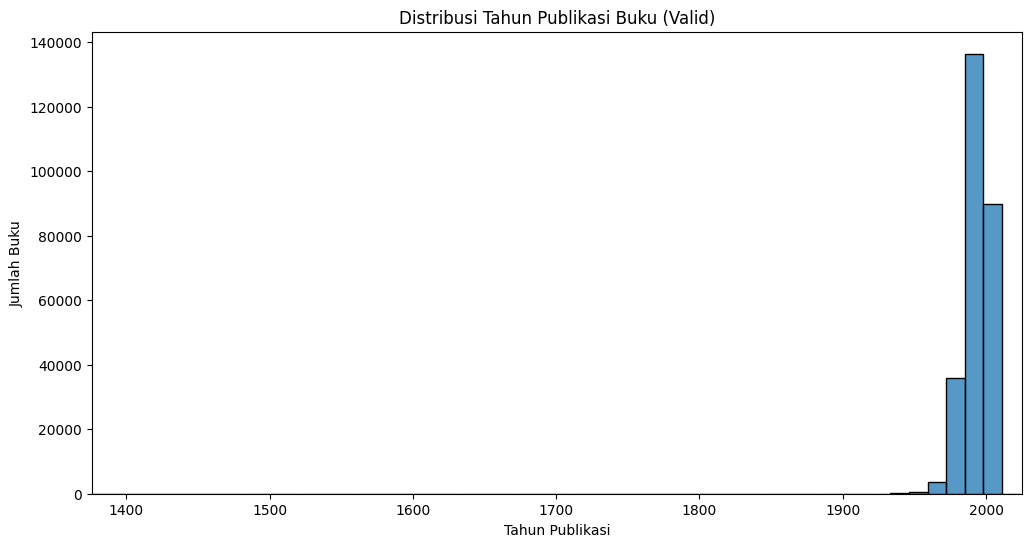

In [85]:
plt.figure(figsize=(12, 6))
sns.histplot(books_cleaned_year['Year-Of-Publication'], bins=50, kde=False)
plt.title('Distribusi Tahun Publikasi Buku (Valid)')
plt.xlabel('Tahun Publikasi')
plt.ylabel('Jumlah Buku')
plt.xlim(books_cleaned_year['Year-Of-Publication'].min(), current_year)

# Simpan ke file
year_dist_path = "/content/dataset/year_distribution.png"
plt.savefig(year_dist_path)
print(f"Visualisasi distribusi tahun publikasi disimpan di: {year_dist_path}")

# Tampilkan grafik di notebook
plt.show()

# Tutup plot
plt.close()

## 5. Data Preparation

*   Menggabungkan data ratings dengan data buku untuk memudahkan proses modeling.   
*   Melakukan pengecekan dan penanganan missing values pada kolom penting.
*   Melakukan filtering data untuk mengurangi sparsity, yaitu hanya mengambil buku dengan minimal 10 rating dan pengguna dengan minimal 5 rating.


Menggabungkan data ratings dengan data buku

In [86]:
print("Menggabungkan data ratings dan books...")
df = ratings.merge(books, on='ISBN', how='left')

Menggabungkan data ratings dan books...


Cek missing values setelah merge

In [87]:
print("Missing values setelah merge:\n", df.isnull().sum())

Missing values setelah merge:
 User-ID                     0
ISBN                        0
Book-Rating                 0
Book-Title             118644
Book-Author            118646
Year-Of-Publication    118648
Publisher              118646
Image-URL-S            118644
Image-URL-M            118644
Image-URL-L            118648
dtype: int64


### Penanganan Missing Values

In [88]:
print("Mengisi missing values pada Book-Author dan Publisher dengan 'Unknown'...")
df['Book-Author'].fillna('Unknown', inplace=True)
df['Publisher'].fillna('Unknown', inplace=True)

Mengisi missing values pada Book-Author dan Publisher dengan 'Unknown'...


<ipython-input-88-b3fa2e7ba233>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Book-Author'].fillna('Unknown', inplace=True)
<ipython-input-88-b3fa2e7ba233>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

Mengatasi sparsity data pada Collaborative Filtering

In [89]:
min_book_ratings = 10
min_user_ratings = 5

print(f"Jumlah data awal: {len(df)}")

Jumlah data awal: 1149780


### Filter buku

In [90]:
book_rating_counts = df['ISBN'].value_counts()
df = df[df['ISBN'].isin(book_rating_counts[book_rating_counts >= min_book_ratings].index)]
print(f"Jumlah data setelah filter buku (min {min_book_ratings} ratings): {len(df)}")

Jumlah data setelah filter buku (min 10 ratings): 536630


### Filter pengguna

In [91]:
user_rating_counts = df['User-ID'].value_counts()
df = df[df['User-ID'].isin(user_rating_counts[user_rating_counts >= min_user_ratings].index)]
print(f"Jumlah data setelah filter pengguna (min {min_user_ratings} ratings): {len(df)}")

Jumlah data setelah filter pengguna (min 5 ratings): 456182


#### Cek ulang dimensi data setelah filtering

Menampilkan jumlah pengguna dan buku unik setelah proses filtering untuk memastikan data sudah lebih bersih dan manageable.

In [92]:
print(f"Jumlah pengguna unik setelah filter: {df['User-ID'].nunique()}")
print(f"Jumlah buku unik setelah filter: {df['ISBN'].nunique()}")

# Reset index
df.reset_index(drop=True, inplace=True)

Jumlah pengguna unik setelah filter: 13808
Jumlah buku unik setelah filter: 18318


## 6. Modeling - Content-Based Filtering

*   Mengambil data buku unik hasil preparation, sampling jika data terlalu besar.  
*   Menggabungkan fitur teks (author dan publisher) untuk digunakan sebagai fitur content-based.
*   Membuat matriks TF-IDF dari fitur gabungan, menghitung cosine similarity antar buku, dan membuat mapping ISBN ke index.  
*   Menyediakan fungsi rekomendasi buku berbasis kemiripan konten.

Menggunakan data buku unik setelah preparation

In [93]:
books_prepared_full = df.drop_duplicates(subset='ISBN').reset_index(drop=True)
print(f"Jumlah buku unik awal untuk Content-Based: {len(books_prepared_full)}")

Jumlah buku unik awal untuk Content-Based: 18318


Penyesuaian Resource: Menggunakan Sampel Data

In [94]:
sample_size_books_cb = 5000
if len(books_prepared_full) > sample_size_books_cb:
    print(f"Mengambil sampel {sample_size_books_cb} buku untuk Content-Based Filtering karena keterbatasan resource.")
    books_prepared = books_prepared_full.sample(n=sample_size_books_cb, random_state=42).reset_index(drop=True)
else:
    print("Ukuran data buku unik sudah cukup kecil, menggunakan semua data.")
    books_prepared = books_prepared_full

print(f"Jumlah buku unik yang digunakan untuk Content-Based (setelah sampling): {len(books_prepared)}")

Mengambil sampel 5000 buku untuk Content-Based Filtering karena keterbatasan resource.
Jumlah buku unik yang digunakan untuk Content-Based (setelah sampling): 5000


#### Menggabungkan fitur teks

In [95]:
books_prepared['content_features'] = books_prepared['Book-Author'] + ' ' + books_prepared['Publisher']

Pastikan semua konten dalam format string dan isi NaN dengan string kosong

In [96]:
books_prepared['content_features'] = books_prepared['content_features'].fillna('').astype(str)

Inisialisasi TF-IDF Vectorizer

In [97]:
tfidf = TfidfVectorizer(stop_words='english')

# Fit and transform
print("Membuat matriks TF-IDF...")
tfidf_matrix = tfidf.fit_transform(books_prepared['content_features'])

Membuat matriks TF-IDF...


Menghitung Cosine Similarity

In [98]:
print("Menghitung cosine similarity...")
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Shape matriks cosine similarity:", cosine_sim.shape)

Menghitung cosine similarity...
Shape matriks cosine similarity: (5000, 5000)


Membuat mapping ISBN ke index

In [99]:
isbn_to_index = pd.Series(books_prepared.index, index=books_prepared['ISBN'])

#### Fungsi rekomendasi Content-Based

In [100]:
def get_content_based_recommendations(isbn, top_n=10):
    if isbn not in isbn_to_index:
        if isbn in books_prepared_full['ISBN'].values:
            try:
                book_full_features = books_prepared_full[books_prepared_full['ISBN'] == isbn]['content_features'].iloc[0]
                input_vector = tfidf.transform([book_full_features])
                sim_scores_input = cosine_similarity(input_vector, tfidf_matrix).flatten()
                sim_indices = sim_scores_input.argsort()[::-1][:top_n]
                recommendations = books_prepared.iloc[sim_indices][['ISBN', 'Book-Title', 'Book-Author', 'Publisher']].copy()
                recommendations['Similarity_Score'] = sim_scores_input[sim_indices]
                return recommendations
            except Exception as e:
                return f"Gagal mendapatkan rekomendasi untuk ISBN {isbn} (tidak di sampel): {e}"
        else:
            return f"ISBN {isbn} tidak ditemukan dalam data asli maupun sampel."

    idx = isbn_to_index[isbn]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    book_indices = [i[0] for i in sim_scores]
    recommendations = books_prepared.iloc[book_indices][['ISBN', 'Book-Title', 'Book-Author', 'Publisher']].copy()
    recommendations['Similarity_Score'] = [s[1] for s in sim_scores]
    return recommendations

## Contoh penggunaan

Menampilkan contoh hasil rekomendasi buku berdasarkan ISBN tertentu menggunakan pendekatan content-based.

In [101]:
if not df.empty:
    example_isbn_cb = df['ISBN'].iloc[0]
    print(f"\nContoh Rekomendasi Content-Based untuk ISBN: {example_isbn_cb}")
    recommendations_cb = get_content_based_recommendations(example_isbn_cb)
    print(recommendations_cb)
else:
    print("\nDataFrame df kosong, tidak dapat mengambil contoh ISBN.")


Contoh Rekomendasi Content-Based untuk ISBN: 0425115801
            ISBN            Book-Title     Book-Author  \
619   0425136981           Shadowfires  Dean R. Koontz   
952   0425099334             Shattered  Dean R. Koontz   
1827  0425181111             Strangers  Dean R. Koontz   
2188  042511984X      The Face of Fear  Dean R. Koontz   
2464  0425132951  The House of Thunder  Dean R. Koontz   
2480  0425115801             Lightning  Dean R. Koontz   
2858  0425100650         Twilight Eyes  Dean R. Koontz   
3491  0425140032          Dragon Tears  Dean R. Koontz   
4638  0425130711             Cold Fire  Dean R. Koontz   
1312  0425192032             Lightning     Dean Koontz   

                     Publisher  Similarity_Score  
619   Berkley Publishing Group          1.000000  
952   Berkley Publishing Group          1.000000  
1827  Berkley Publishing Group          1.000000  
2188  Berkley Publishing Group          1.000000  
2464  Berkley Publishing Group          1.000000 

## 7. Modeling - Collaborative Filtering

*   Menggunakan data rating eksplisit (rating > 0) dan melakukan sampling pengguna serta buku jika data terlalu besar.
*   Membuat user-item matrix, melakukan SVD untuk dekomposisi matriks, dan membangun fungsi rekomendasi berbasis prediksi rating hasil SVD.

Menggunakan rating eksplisit (rating > 0)

In [102]:
df_explicit_full = df[df['Book-Rating'] > 0].copy()

Penyesuaian Resource: Menggunakan Sampel Data (Pengguna & Buku)

#### Ambil sampel pengguna

In [103]:
max_users_cf = 5000
all_user_ids = df_explicit_full['User-ID'].unique()
if len(all_user_ids) > max_users_cf:
    print(f"Mengambil sampel {max_users_cf} pengguna untuk Collaborative Filtering karena keterbatasan resource.")
    sampled_user_ids = np.random.choice(all_user_ids, max_users_cf, replace=False)
    df_explicit = df_explicit_full[df_explicit_full['User-ID'].isin(sampled_user_ids)]
else:
    print("Jumlah pengguna sudah cukup kecil, menggunakan semua pengguna.")
    df_explicit = df_explicit_full

# Ambil sampel buku (berdasarkan rating dari pengguna sampel)
max_books_cf = 5000
all_isbn_ids_sampled_users = df_explicit['ISBN'].unique()
if len(all_isbn_ids_sampled_users) > max_books_cf:
    print(f"Mengambil sampel {max_books_cf} buku (dari pengguna sampel) untuk Collaborative Filtering.")
    sampled_isbn_ids = np.random.choice(all_isbn_ids_sampled_users, max_books_cf, replace=False)
    df_explicit = df_explicit[df_explicit['ISBN'].isin(sampled_isbn_ids)]
else:
    print("Jumlah buku (dari pengguna sampel) sudah cukup kecil, menggunakan semua buku.")

print(f"Jumlah data rating setelah sampling pengguna & buku: {len(df_explicit)}")

Mengambil sampel 5000 pengguna untuk Collaborative Filtering karena keterbatasan resource.
Mengambil sampel 5000 buku (dari pengguna sampel) untuk Collaborative Filtering.
Jumlah data rating setelah sampling pengguna & buku: 20238


Buat mapping User-ID dan ISBN ke integer index (untuk data sampel CF)

In [104]:
user_ids_cf = df_explicit['User-ID'].unique()
user_id_map_cf = {id: i for i, id in enumerate(user_ids_cf)}
df_explicit['user_idx'] = df_explicit['User-ID'].map(user_id_map_cf)

isbn_ids_cf = df_explicit['ISBN'].unique()
isbn_id_map_cf = {id: i for i, id in enumerate(isbn_ids_cf)}
isbn_map_reverse_cf = {i: id for i, id in enumerate(isbn_ids_cf)}
df_explicit['isbn_idx'] = df_explicit['ISBN'].map(isbn_id_map_cf)

print(f"Jumlah pengguna unik (setelah sampling CF): {df_explicit['user_idx'].nunique()}")
print(f"Jumlah buku unik (setelah sampling CF): {df_explicit['isbn_idx'].nunique()}")

Jumlah pengguna unik (setelah sampling CF): 4123
Jumlah buku unik (setelah sampling CF): 5000


Membuat pivot table (user-item matrix) dari data sampel CF

In [105]:
print("Membuat User-Item Interaction Matrix (dari data sampel CF)...")
try:
    user_item_matrix = df_explicit.pivot_table(index='user_idx', columns='isbn_idx', values='Book-Rating').fillna(0)
except MemoryError:
    print("Error: Masih terjadi MemoryError saat membuat pivot table. Coba kurangi max_users_cf atau max_books_cf.")
    exit()
except Exception as e:
    print(f"Error saat membuat pivot table: {e}")
    exit()

Membuat User-Item Interaction Matrix (dari data sampel CF)...


Konversi ke numpy array

In [109]:
user_item_matrix_np = user_item_matrix.values

Tambahan: Normalisasi dengan mengurangi rata-rata user

Melakukan Singular Value Decomposition (SVD)

In [112]:
k = 50
print(f"Melakukan SVD dengan k={k}...")
try:
    # Pastikan k tidak lebih besar dari dimensi matriks
    k_svd = min(k, user_item_matrix_np.shape[0] - 1, user_item_matrix_np.shape[1] - 1)
    if k_svd < 1:
        raise ValueError("Dimensi matriks terlalu kecil untuk SVD setelah sampling.")
    print(f"Menggunakan k={k_svd} untuk SVD.")
    U, sigma, Vt = svds(user_item_matrix_np, k=k_svd)
except ValueError as ve:
    print(f"Error saat melakukan SVD: {ve}")
    U, sigma, Vt = None, None, None # Tandai gagal
except Exception as e:
    print(f"Error tidak terduga saat SVD: {e}")
    U, sigma, Vt = None, None, None # Tandai gagal

Melakukan SVD dengan k=50...
Menggunakan k=50 untuk SVD.


Lanjutkan hanya jika SVD berhasil

In [113]:
if U is not None:
    # Memprediksi semua rating
    sigma_diag_matrix = np.diag(sigma)
    all_user_predicted_ratings = np.dot(np.dot(U, sigma_diag_matrix), Vt)

    # Buat DataFrame dari hasil prediksi rating
    preds_df = pd.DataFrame(all_user_predicted_ratings, index=user_item_matrix.index, columns=user_item_matrix.columns)

    # Fungsi rekomendasi Collaborative Filtering (SVD)
    def get_collaborative_svd_recommendations(user_id, top_n=10):
        if user_id not in user_id_map_cf:
            if user_id in df_explicit_full['User-ID'].unique():
                return f"User-ID {user_id} ada di data asli, tetapi tidak termasuk dalam sampel pengguna untuk CF."
            else:
                return f"User-ID {user_id} tidak ditemukan dalam data rating eksplisit asli."

        user_idx = user_id_map_cf[user_id]

        if user_idx not in preds_df.index:
             return f"Internal Error: User index {user_idx} tidak ditemukan di matriks prediksi."

        predicted_ratings_row = preds_df.loc[user_idx]

        if user_idx in user_item_matrix.index:
            rated_isbn_indices = user_item_matrix.loc[user_idx][user_item_matrix.loc[user_idx] > 0].index
        else:
            rated_isbn_indices = pd.Index([])

        predicted_ratings_unrated = predicted_ratings_row.drop(rated_isbn_indices, errors='ignore')
        top_indices = predicted_ratings_unrated.nlargest(top_n).index
        recommended_isbns = [isbn_map_reverse_cf[idx] for idx in top_indices]

        recommended_books = books_prepared_full[books_prepared_full['ISBN'].isin(recommended_isbns)].drop_duplicates(subset='ISBN')

        recommendations = recommended_books[['ISBN', 'Book-Title', 'Book-Author', 'Publisher']].copy()
        pred_scores = predicted_ratings_unrated[top_indices].to_dict()
        recommendations['Predicted_Rating'] = recommendations['ISBN'].map(lambda x: pred_scores.get(isbn_id_map_cf.get(x)))
        recommendations.dropna(subset=['Predicted_Rating'], inplace=True)
        recommendations = recommendations.sort_values(by='Predicted_Rating', ascending=False)

        return recommendations

## Contoh penggunaan (pilih satu User-ID dari data sampel CF)

Menampilkan contoh hasil rekomendasi buku untuk salah satu User-ID menggunakan pendekatan collaborative filtering (SVD).


In [114]:
    if not df_explicit.empty:
        example_user_id_cf = df_explicit['User-ID'].iloc[0]
        print(f"\nContoh Rekomendasi Collaborative Filtering (SVD) untuk User-ID (dari sampel): {example_user_id_cf}")
        recommendations_cf = get_collaborative_svd_recommendations(example_user_id_cf)
        print(recommendations_cf)
    else:
        print("\nDataFrame df_explicit (setelah sampling CF) kosong, tidak dapat mengambil contoh User-ID.")


Contoh Rekomendasi Collaborative Filtering (SVD) untuk User-ID (dari sampel): 276859
             ISBN                                         Book-Title  \
329    1558743669  A Child Called \It\": One Child's Courage to S...   
5702   0670894605                            The Secret Life of Bees   
6572   0345422783  How Reading Changed My Life (Library of Contem...   
650    0877017883  Griffin &amp; Sabine: An Extraordinary Corresp...   
12663  0805061762  A Gentle Madness : Bibliophiles, Bibliomanes, ...   
3852   0385508417                                 Skipping Christmas   
538    0451169522                                             Misery   
3629   0451205073                                        Last Breath   
4939   031242227X                    Running with Scissors: A Memoir   
2253   0345423097            Joy School (Ballantine Reader's Circle)   

                Book-Author              Publisher  Predicted_Rating  
329             Dave Pelzer  Health Communications

## 8. Evaluation

Menghitung dan menampilkan nilai RMSE (Root Mean Squared Error) dari hasil prediksi SVD pada data training (sampel CF) untuk mengukur performa model collaborative filtering.

Evaluasi SVD menggunakan RMSE pada data training (sampel CF)

In [115]:
from sklearn.metrics import mean_squared_error

mask = user_item_matrix_np > 0
original_ratings = user_item_matrix_np[mask]
predicted_ratings = all_user_predicted_ratings[mask]

if len(original_ratings) > 0:
    rmse = np.sqrt(mean_squared_error(original_ratings, predicted_ratings))
    print(f"\nRMSE (Root Mean Squared Error) SVD pada data training (sampel CF): {rmse:.4f}")
else:
    print("\nTidak ada rating asli > 0 dalam matriks sampel CF untuk menghitung RMSE.")


RMSE (Root Mean Squared Error) SVD pada data training (sampel CF): 6.5812
